# LAB #11: Optical Flow Estimation

**Objective:** Implement and analyze two optical flow techniques:
1. **KLT (Kanade-Lucas-Tomasi)** — Sparse optical flow using Shi-Tomasi + Lucas-Kanade
2. **Farneback Dense Optical Flow** — Dense motion estimation for every pixel

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

print(f'OpenCV version: {cv2.__version__}')

OpenCV version: 4.13.0


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
VIDEO_PATH    = r'E:\Computer Vision\LAB\lab10\highway (1).mp4'   # input video
KLT_OUT_PATH  = r'E:\Computer Vision\LAB\lab10\task1_klt_output.mp4'
MAX_FRAMES    = 300                  # number of frames to process

# Shi-Tomasi corner detection parameters
SHI_TOMASI_PARAMS = dict(
    maxCorners   = 200,    # maximum number of corners to detect
    qualityLevel = 0.01,   # minimum quality of corners (0-1)
    minDistance  = 30,     # minimum Euclidean distance between corners
    blockSize    = 7       # neighbourhood size for covariance matrix
)

# Lucas-Kanade optical flow parameters
LK_PARAMS = dict(
    winSize  = (21, 21),                                            # search window size
    maxLevel = 3,                                                    # pyramid levels
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,    # stop when …
                30, 0.001)                                           # … 30 iters OR eps < 0.001
)

REDETECT_INTERVAL = 30  # re-detect features every N frames

print('Parameters configured.')

Parameters configured.


In [6]:
def detect_features(gray):
    """Detect good features (corners) using Shi-Tomasi method."""
    return cv2.goodFeaturesToTrack(gray, **SHI_TOMASI_PARAMS)

def draw_tracks(frame, cur_pts, prev_pts, mask, colors):
    """
    Draw motion trails (lines) and current point positions (circles).
    Returns the annotated frame and the updated trail mask.
    """
    for i, (new, old) in enumerate(zip(cur_pts, prev_pts)):
        a, b = new.ravel().astype(int)   # current position
        c, d = old.ravel().astype(int)   # previous position
        color = colors[i % len(colors)].tolist()
        mask  = cv2.line(mask, (a, b), (c, d), color, 2)   # trail
        frame = cv2.circle(frame, (a, b), 5, color, -1)    # point
    return cv2.add(frame, mask), mask

print('Helper functions defined.')

Helper functions defined.


In [7]:
# ── Run KLT tracking ──────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS)
print(f'Video: {W}×{H} @ {FPS:.1f} fps')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out    = cv2.VideoWriter(KLT_OUT_PATH, fourcc, FPS, (W, H))

rng    = np.random.default_rng(42)
colors = rng.integers(50, 255, (200, 3), dtype=np.uint8)

ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0       = detect_features(old_gray)
mask     = np.zeros_like(old_frame)
frame_idx = 0

while frame_idx < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Re-detect features periodically or when too few remain
    if p0 is None or len(p0) < 10 or frame_idx % REDETECT_INTERVAL == 0:
        p0   = detect_features(old_gray)
        mask = np.zeros_like(frame)   # reset trails

    if p0 is None:
        out.write(frame)
        old_gray = frame_gray.copy()
        continue

    # Compute Lucas-Kanade optical flow (pyramidal)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **LK_PARAMS)

    if p1 is None:
        out.write(frame)
        old_gray = frame_gray.copy()
        p0 = None
        continue

    # Keep only points that were successfully tracked (status == 1)
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    vis, mask = draw_tracks(frame.copy(), good_new, good_old, mask, colors)

    # Overlay info
    cv2.putText(vis, f'KLT Optical Flow  |  Frame {frame_idx}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
    cv2.putText(vis, f'Tracked points: {len(good_new)}',
                (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    out.write(vis)
    old_gray = frame_gray.copy()
    p0       = good_new.reshape(-1, 1, 2)

cap.release()
out.release()
print(f'✓ KLT output saved → {KLT_OUT_PATH}  ({frame_idx} frames)')

Video: 1280×720 @ 30.0 fps
✓ KLT output saved → E:\Computer Vision\LAB\lab10\task1_klt_output.mp4  (300 frames)


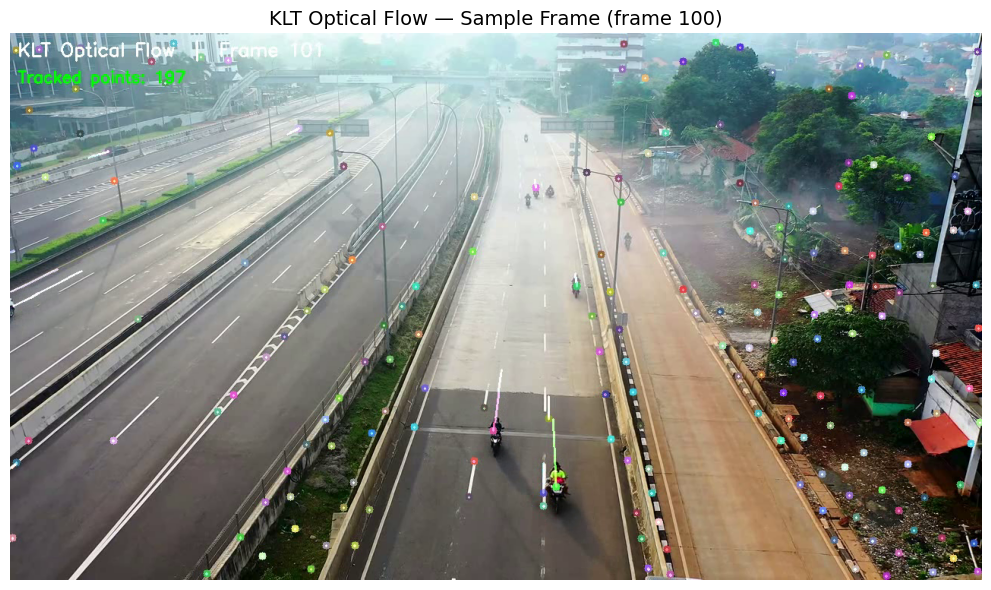

In [8]:
# ── Visualise a sample frame from the KLT output ──────────────────────────────
cap = cv2.VideoCapture(KLT_OUT_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)        # jump to frame 100
ret, sample = cap.read()
cap.release()

plt.figure(figsize=(14, 6))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title('KLT Optical Flow — Sample Frame (frame 100)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Task 2: Farneback Dense Optical Flow

### Theory
Unlike KLT, the **Farneback** method is **dense** — it computes a motion vector for *every pixel*.  
Key ideas:
- Local image regions are approximated by **quadratic polynomials**
- Motion is estimated by comparing these polynomial representations between consecutive frames
- A **Gaussian pyramid** is used to handle larger displacements

**Visualisation strategy:**
- Encode flow in **HSV colour space**: hue = direction, value = magnitude
- Side-by-side: HSV colour map | motion arrow overlay

In [9]:
# ── Farneback configuration ───────────────────────────────────────────────────
FB_OUT_PATH = 'task2_farneback_output.avi'
MAX_FRAMES  = 150    # frames to process
SCALE       = 0.667  # down-scale to reduce computation (≈480p)

# Farneback algorithm parameters
FB_PARAMS = dict(
    pyr_scale  = 0.5,  # scale between pyramid levels (0.5 = classic Gaussian pyramid)
    levels     = 3,    # number of pyramid levels
    winsize    = 15,   # averaging window size (larger = smoother but slower)
    iterations = 3,    # iterations at each pyramid level
    poly_n     = 5,    # pixel neighbourhood for polynomial expansion (5 or 7)
    poly_sigma = 1.2,  # Gaussian std-dev for poly smoothing (1.1–1.5 typical)
    flags      = 0
)

print('Farneback parameters configured.')
print('  pyr_scale  :', FB_PARAMS['pyr_scale'],  '→ each level shrinks by 50%')
print('  levels     :', FB_PARAMS['levels'],     '→ 3-level pyramid')
print('  winsize    :', FB_PARAMS['winsize'],    '→ 15×15 averaging window')
print('  poly_n     :', FB_PARAMS['poly_n'],     '→ 5×5 polynomial neighbourhood')

Farneback parameters configured.
  pyr_scale  : 0.5 → each level shrinks by 50%
  levels     : 3 → 3-level pyramid
  winsize    : 15 → 15×15 averaging window
  poly_n     : 5 → 5×5 polynomial neighbourhood


In [10]:
def flow_to_hsv_bgr(flow):
    """
    Convert (H,W,2) optical flow to a colour BGR image.
    - Hue    → flow direction  (0°–360° mapped to 0–180 in OpenCV HSV)
    - Saturation → fixed at 255 (full colour)
    - Value  → flow magnitude  (normalised 0–255)
    """
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    H, W = flow.shape[:2]
    hsv = np.zeros((H, W, 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)          # direction → hue
    hsv[..., 1] = 255                                                  # full saturation
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def overlay_arrows(frame, flow, step=32, scale=3.0):
    """
    Overlay a sparse grid of motion arrows on the frame.
    `step`  : grid spacing in pixels
    `scale` : arrow length multiplier
    """
    H, W = frame.shape[:2]
    vis  = frame.copy()
    for y in range(step, H - step, step):
        for x in range(step, W - step, step):
            fx, fy = flow[y, x]
            x2 = int(x + fx * scale)
            y2 = int(y + fy * scale)
            cv2.arrowedLine(vis, (x, y), (x2, y2), (0, 255, 0), 1, tipLength=0.4)
    return vis

print('Helper functions defined.')

Helper functions defined.


In [11]:
# ── Run Farneback dense optical flow ─────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
W0  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H0  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = int(cap.get(cv2.CAP_PROP_FPS))

# Down-scale for faster processing
scale_f = 480.0 / H0
W = int(W0 * scale_f)
H = 480
print(f'Processing at {W}×{H} (down-scaled from {W0}×{H0})')

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out    = cv2.VideoWriter(FB_OUT_PATH, fourcc, FPS, (W * 2, H))

ret, prev = cap.read()
prev_small = cv2.resize(prev, (W, H))
pg = cv2.cvtColor(prev_small, cv2.COLOR_BGR2GRAY)
count = 0

for _ in range(MAX_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break

    frame_small = cv2.resize(frame, (W, H))
    cg = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)

    # ── Core: dense Farneback optical flow ───────────────────────────────────
    flow = cv2.calcOpticalFlowFarneback(
        pg, cg, None,
        FB_PARAMS['pyr_scale'], FB_PARAMS['levels'],
        FB_PARAMS['winsize'],   FB_PARAMS['iterations'],
        FB_PARAMS['poly_n'],    FB_PARAMS['poly_sigma'],
        FB_PARAMS['flags']
    )

    # Visualise: HSV colour map
    color_vis = flow_to_hsv_bgr(flow)

    # Visualise: arrow overlay on original frame
    arrow_vis = overlay_arrows(frame_small.copy(), flow, step=32, scale=3.0)

    # Add labels
    for img, label in [(color_vis, 'Dense Flow (HSV colour)'), (arrow_vis, 'Arrow Overlay')]:
        cv2.putText(img, label,   (8, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
        cv2.putText(img, f'Frame {count+1}', (8, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,0), 2)

    out.write(np.hstack([color_vis, arrow_vis]))
    pg = cg.copy()
    count += 1

cap.release()
out.release()
print(f'✓ Farneback output saved → {FB_OUT_PATH}  ({count} frames)')

Processing at 853×480 (down-scaled from 1280×720)
✓ Farneback output saved → task2_farneback_output.avi  (150 frames)


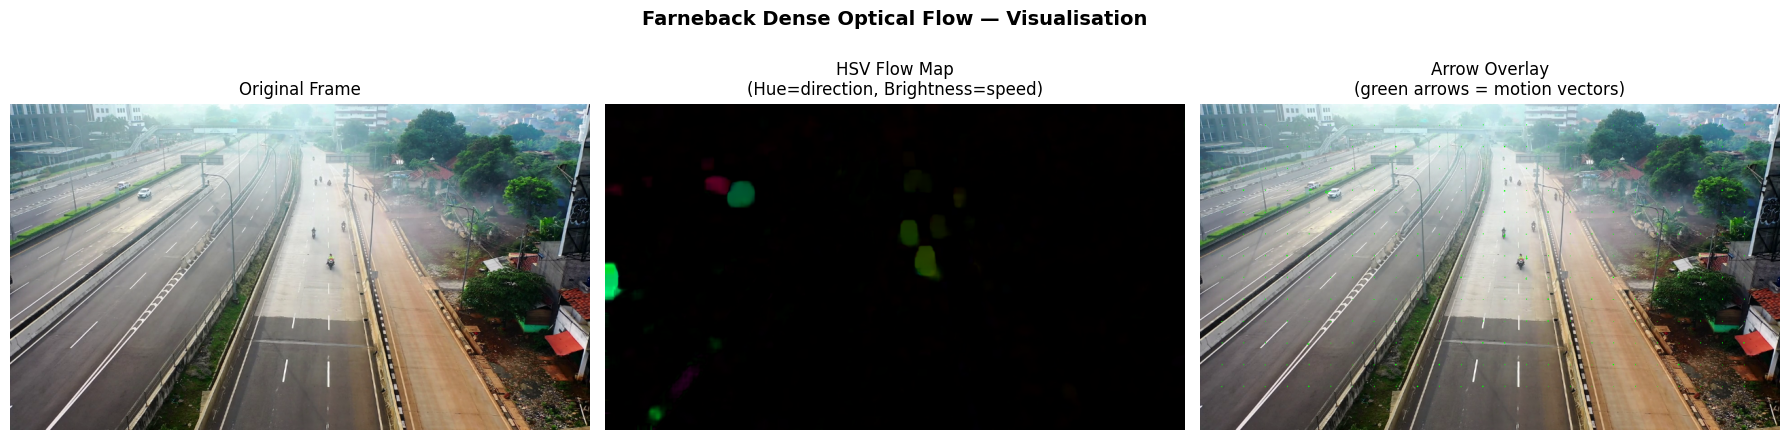

Plot saved as farneback_sample.png


In [12]:
# ── Visualise: Farneback sample frame + colour wheel legend ───────────────────

# Read a sample frame pair from the video for illustration
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, f1 = cap.read()
ret, f2 = cap.read()
cap.release()

scale_f = 480.0 / f1.shape[0]
W_s = int(f1.shape[1] * scale_f)
f1s = cv2.resize(f1, (W_s, 480))
f2s = cv2.resize(f2, (W_s, 480))

g1 = cv2.cvtColor(f1s, cv2.COLOR_BGR2GRAY)
g2 = cv2.cvtColor(f2s, cv2.COLOR_BGR2GRAY)
flow_sample = cv2.calcOpticalFlowFarneback(g1, g2, None,
    FB_PARAMS['pyr_scale'], FB_PARAMS['levels'], FB_PARAMS['winsize'],
    FB_PARAMS['iterations'], FB_PARAMS['poly_n'], FB_PARAMS['poly_sigma'], FB_PARAMS['flags'])

color_vis  = flow_to_hsv_bgr(flow_sample)
arrow_vis  = overlay_arrows(f2s.copy(), flow_sample)
mag_vis    = cv2.normalize(np.sqrt(flow_sample[...,0]**2 + flow_sample[...,1]**2),
                            None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(f2s, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Frame', fontsize=12)
axes[1].imshow(cv2.cvtColor(color_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title('HSV Flow Map\n(Hue=direction, Brightness=speed)', fontsize=12)
axes[2].imshow(cv2.cvtColor(arrow_vis, cv2.COLOR_BGR2RGB))
axes[2].set_title('Arrow Overlay\n(green arrows = motion vectors)', fontsize=12)
for ax in axes: ax.axis('off')
plt.suptitle('Farneback Dense Optical Flow — Visualisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('farneback_sample.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved as farneback_sample.png')

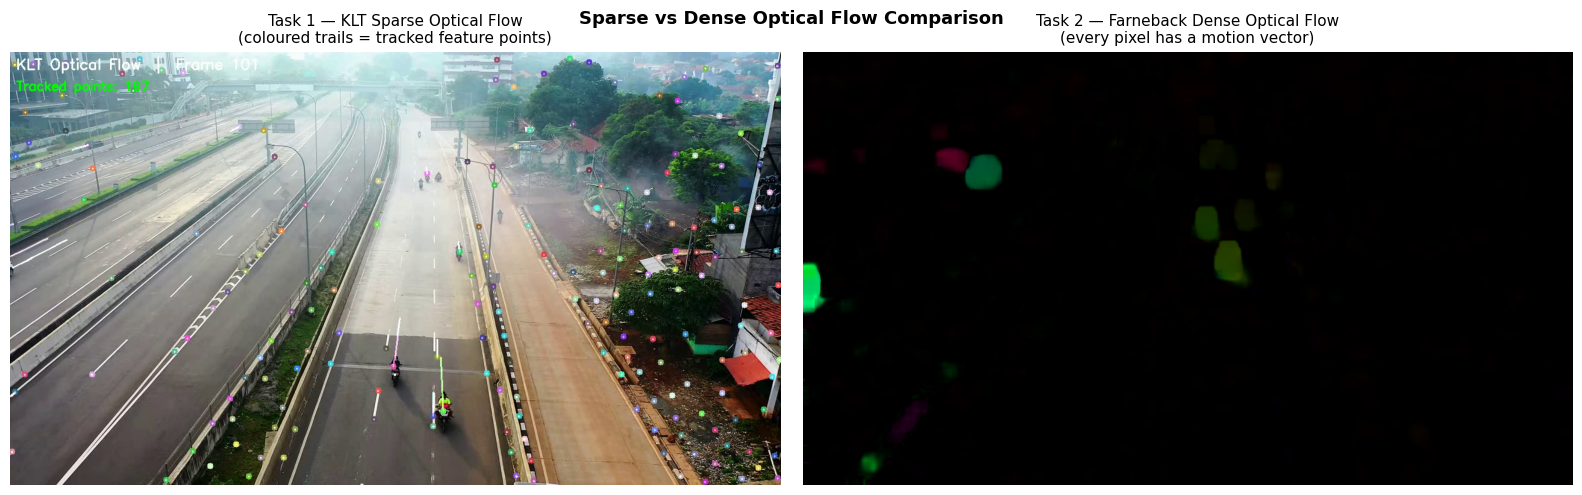

Comparison plot saved as comparison.png


In [13]:
# ── Side-by-side comparison: KLT sample vs Farneback colour map ──────────────
cap_klt = cv2.VideoCapture(KLT_OUT_PATH)
cap_klt.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, klt_frame = cap_klt.read()
cap_klt.release()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(klt_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Task 1 — KLT Sparse Optical Flow\n(coloured trails = tracked feature points)', fontsize=11)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(color_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title('Task 2 — Farneback Dense Optical Flow\n(every pixel has a motion vector)', fontsize=11)
axes[1].axis('off')
plt.suptitle('Sparse vs Dense Optical Flow Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Comparison plot saved as comparison.png')

---
## Summary

| | KLT (Sparse) | Farneback (Dense) |
|---|---|---|
| **Coverage** | Selected keypoints only | Every pixel |
| **Speed** | Fast (real-time capable) | Slower |
| **Detail** | Low — only tracked features | High — full motion field |
| **Feature detection** | Shi-Tomasi corners | Not needed |
| **Flow method** | Lucas-Kanade (windowed) | Polynomial expansion |
| **Best for** | Object/face tracking, SLAM | Motion segmentation, video stabilisation |

### Key Observations
- **KLT** clearly shows individual vehicle trajectories as coloured trails; fast and interpretable
- **Farneback** reveals the full scene motion: background (camera motion if any) vs moving vehicles, encoded as colour hue
- Both methods rely on the **brightness constancy assumption**, which can fail under lighting changes or rapid motion